In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor

In [1]:
!pip install tqdm

## Task
First let's fit our supernova synthetic data from last time using GPR.

* The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
* Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
* But check out what's available in the kernels submodule of sklearn.gaussian_process
* Plot the expectation value of the fit as well as the resulting 1-$\sigma$  and 2-$\sigma$ contours.
* Interpret the results.

Note. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.

Think about the pdf of these data in z. Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given.

(35.0, 50.0)

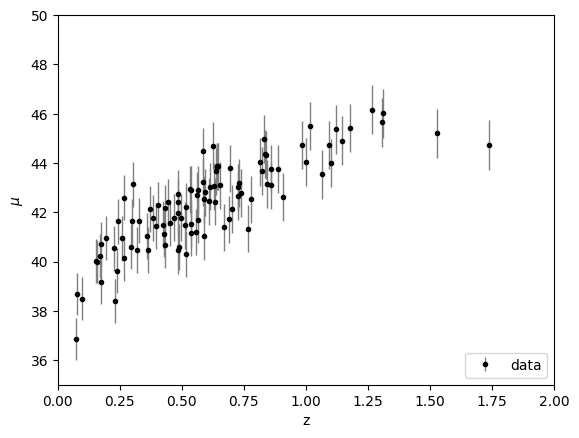

In [9]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [10]:
kernel = RBF(0.5, (0.01, 10.0))
gp = GaussianProcessRegressor(kernel=kernel,
                               alpha=dmu ** 2)
x = np.linspace(0,2,100)
gp.fit(z_sample[:, None], mu_sample)
mu_fitted, sigma_fit = gp.predict(x[:, None], 
                         return_std=True)

# we have fit for the `h` parameter: print the result here:
print("best-fit theta =", gp.kernel_.theta[0])

best-fit theta = 0.9225046869266914


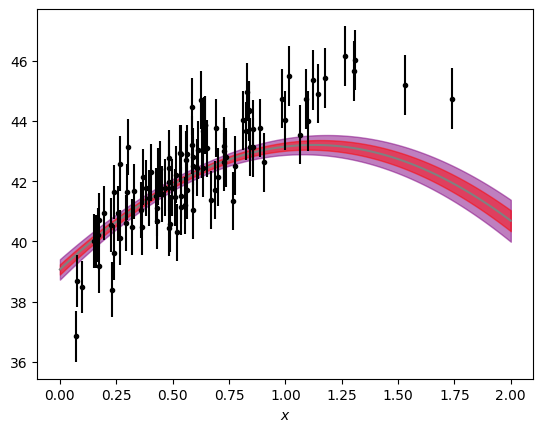

In [11]:
fig, ax = plt.subplots()
ax.plot(x, mu_fitted, '-', color='gray')
ax.fill_between(x, mu_fitted - 2* sigma_fit, mu_fitted + 2 * sigma_fit, alpha=0.5,
                color='purple', 
                label='2-$\sigma$ level')
ax.fill_between(x, mu_fitted -  sigma_fit, mu_fitted +  sigma_fit, alpha=0.5,
                color='red', 
                label='1-$\sigma$ level')
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ms=6)

ax.set_xlabel('$x$')


plt.show()

In [12]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# parameters grid
l_range = np.linspace(0.01,10)
k = 8
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_errors_gpr = []

for l in l_range:
    v_err = []
    # kernel fixed for internal iterations
    kernel = RBF(length_scale=l)
    
    for train_idx, val_idx in kf.split(z_sample):
        z_tr, z_vl = z_sample[train_idx, np.newaxis], z_sample[val_idx, np.newaxis]
        mu_tr, mu_vl = mu_sample[train_idx], mu_sample[val_idx]
        dmu_tr = dmu[train_idx]
        
        gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu_tr**2, optimizer=None)
        gp.fit(z_tr, mu_tr)
        
        y_pred = gp.predict(z_vl)
        v_err.append(mean_squared_error(mu_vl, y_pred))
        
    cv_errors_gpr.append(np.mean(v_err))


best_l = l_range[np.argmin(cv_errors_gpr)]
print(f"Best length_scale: {best_l:.3f}")

Best length_scale: 2.253


Text(0.5, 1.0, 'GPR best fit (l=2.25)')

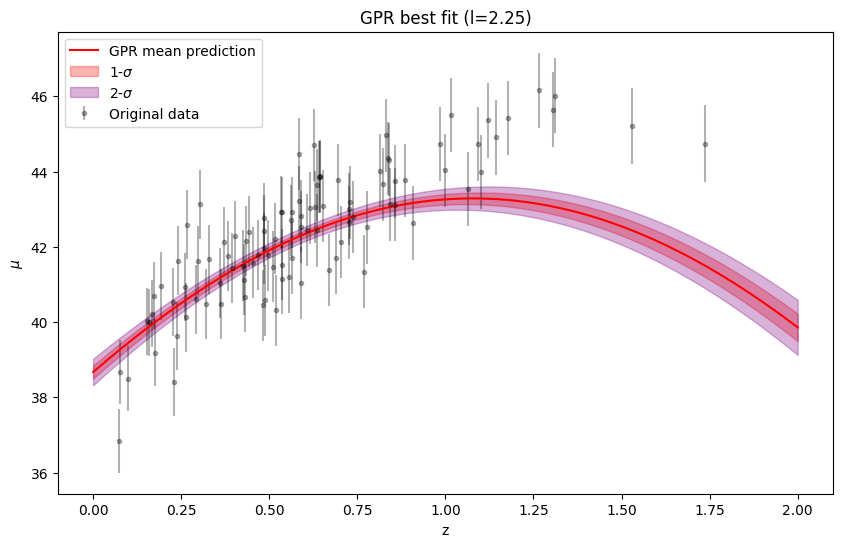

In [13]:
best_kernel = RBF(length_scale=best_l)
gp_final = GaussianProcessRegressor(kernel=best_kernel, alpha=dmu**2, optimizer=None)
gp_final.fit(z_sample[:, np.newaxis], mu_sample)

z = np.linspace(0, 2, 200)[:, np.newaxis]
mu_pred, sigma_pred = gp_final.predict(z, return_std=True)

plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', alpha=0.3, label='Original data')
plt.plot(z, mu_pred, 'r-', label='GPR mean prediction')


plt.fill_between(z.flatten(), mu_pred - sigma_pred, mu_pred + sigma_pred, color='red', alpha=0.3, label=r'1-$\sigma$')
plt.fill_between(z.flatten(), mu_pred - 2*sigma_pred, mu_pred + 2*sigma_pred, color='purple', alpha=0.3, label=r'2-$\sigma$')

plt.xlabel('z')
plt.ylabel('$\mu$')
plt.legend()
plt.title(f"GPR best fit (l={best_l:.2f})")

In [14]:

from sklearn.gaussian_process.kernels import  ConstantKernel as C


c_range = np.logspace(-1, 5, 10)  # Amplitude
l_range = np.logspace(-2, 3, 10) # scale

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)


grid_errors = np.zeros((len(c_range), len(l_range)))

for i, c_val in enumerate(c_range):
    for j, l_val in enumerate(l_range):
        v_err = []
        kernel = C(c_val) * RBF(length_scale=l_val)
        
        for train_idx, val_idx in kf.split(z_sample):
            z_tr, z_vl = z_sample[train_idx, np.newaxis], z_sample[val_idx, np.newaxis]
            mu_tr, mu_vl = mu_sample[train_idx], mu_sample[val_idx]
            dmu_tr = dmu[train_idx]
            
            # optimizer=None 
            gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu_tr**2, optimizer=None)
            gp.fit(z_tr, mu_tr)
            
            y_pred = gp.predict(z_vl)
            v_err.append(mean_squared_error(mu_vl, y_pred))
            
        grid_errors[i, j] = np.mean(v_err)


idx_c, idx_l = np.unravel_index(np.argmin(grid_errors), grid_errors.shape)
best_c = c_range[idx_c]
best_l = l_range[idx_l]

print(f"Bets Constant C: {best_c:.2f}")
print(f"Best Length-scale l: {best_l:.2f}")

Bets Constant C: 215.44
Best Length-scale l: 1.67


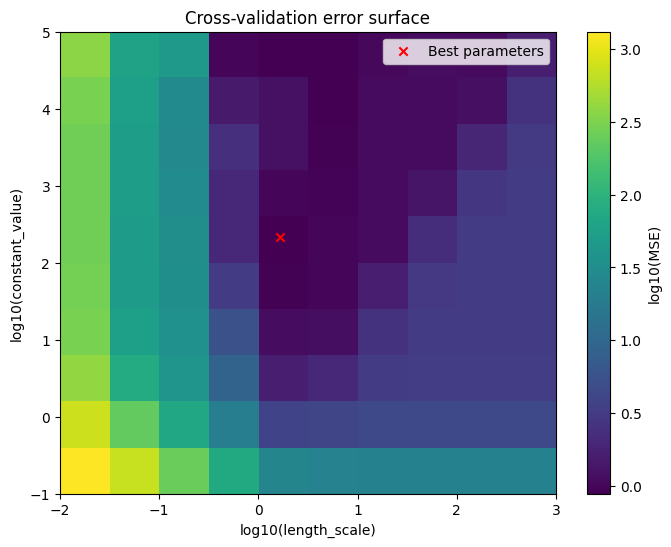

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(np.log10(grid_errors), extent=[np.log10(l_range.min()), np.log10(l_range.max()), 
                                          np.log10(c_range.min()), np.log10(c_range.max())],
           aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='log10(MSE)')
plt.scatter(np.log10(best_l), np.log10(best_c), color='red', marker='x', label='Best parameters')
plt.xlabel('log10(length_scale)')
plt.ylabel('log10(constant_value)')
plt.title('Cross-validation error surface')
plt.legend()
plt.show()

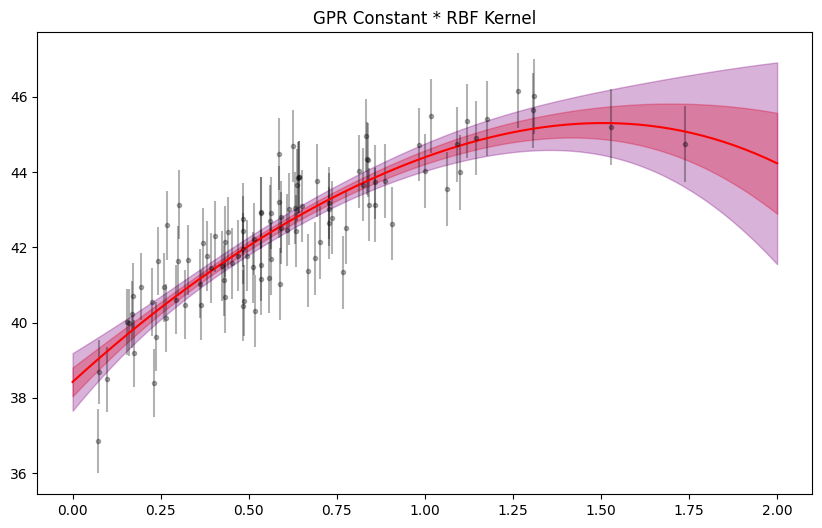

In [16]:
best_kernel = C(best_c) * RBF(length_scale=best_l)
gp_final = GaussianProcessRegressor(kernel=best_kernel, alpha=dmu**2, optimizer=None)
gp_final.fit(z_sample[:, np.newaxis], mu_sample)

z = np.linspace(0, 2, 200)[:, np.newaxis]
mu_pred, sigma_pred = gp_final.predict(z, return_std=True)

plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', alpha=0.3)
plt.plot(z, mu_pred, 'r-', label=f'GPR fit (C={best_c:.1f}, l={best_l:.2f})')
plt.fill_between(z.flatten(), mu_pred - sigma_pred, mu_pred + sigma_pred, color='red', alpha=0.3)
plt.fill_between(z.flatten(), mu_pred - 2*sigma_pred, mu_pred + 2*sigma_pred, color='purple', alpha=0.3)
plt.title("GPR Constant * RBF Kernel")
plt.show()

(array([12., 15., 24., 23., 11.,  5.,  5.,  3.,  1.,  1.]),
 array([0.07346547, 0.23986399, 0.40626252, 0.57266104, 0.73905956,
        0.90545809, 1.07185661, 1.23825513, 1.40465366, 1.57105218,
        1.7374507 ]),
 <BarContainer object of 10 artists>)

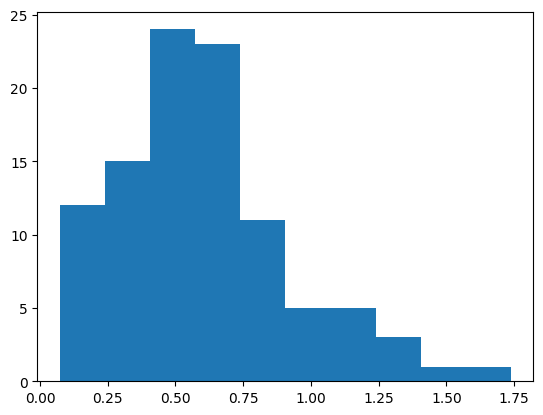

In [17]:
plt.hist(z_sample)

In [18]:
from sklearn.neighbors import KernelDensity

z_data = z_sample[:, np.newaxis]
kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_data)


z_cloned = kde.sample(1000, random_state=42)
z_cloned = np.sort(z_cloned, axis=0) 

In [19]:
from sklearn.model_selection import GridSearchCV

bandwidths = np.linspace(0.01, 1.5, 60)
grid = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=5, n_jobs=-1)
grid.fit(z_data)

best_bw = grid.best_params_['bandwidth']
print(f"Best bandwidth: {best_bw:.3f}")

kde = grid.best_estimator_
z_cloned = kde.sample(1000, random_state=42)
z_cloned = np.sort(z_cloned, axis=0)

Best bandwidth: 0.136


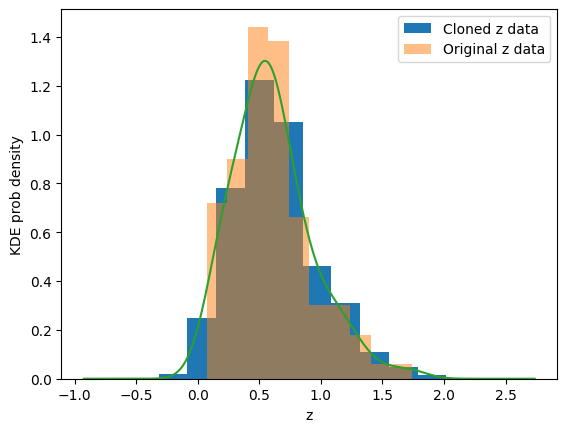

In [20]:
plt.hist(z_cloned, density=True, label= 'Cloned z data')
plt.hist(z_sample, density=True, alpha =0.5, label= 'Original z data')
z_ax = np.linspace(z_data.min() - 1, z_data.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_ax)

plt.plot(z_ax[:, 0], np.exp(log_dens))
plt.xlabel('z')
plt.ylabel('KDE prob density')
plt.legend()
plt.show()

In [21]:

mu_mean, mu_sigma = gp_final.predict(z_cloned, return_std = True)
cloned_mu = np.random.normal(loc=mu_mean,scale=mu_sigma)

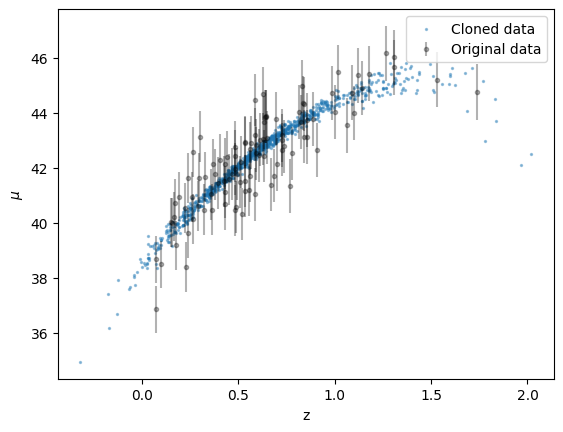

In [22]:
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', alpha=0.3, label ='Original data')
plt.scatter(z_cloned, cloned_mu, s=2, alpha=0.4, label ='Cloned data')

plt.xlabel('z')
plt.ylabel('$\mu$')
plt.legend()


## Task

We now have a suite of data-driven predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$ CDM. We can do a parametric fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

Assuming a flat Universe, we have a parametric non-linear model for $\mu (z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$

It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:

* Set up a Bayesian framework and MCMC and/or nested sampling.
* Set up a fully-connected neural network (see end of the class).

What are the measured values of $H_0$ and $\Omega_m$. What are they errors? Are they correlated?

How would a model without dark energy perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem)


### MCMC

In [65]:
import emcee
from astropy.cosmology import LambdaCDM
import scipy.integrate as integrate

c = 299792.458 # km/s

def mu_model(z, h0, om):
    # integrand E(z)
    def Ez(z_prime, om):
        return 1.0 / np.sqrt(om * (1 + z_prime)**3 + (1 - om))
    
    # integral of comoving distance
    integral, _ = integrate.quad(Ez, 0, z, args=(om))
    dl = (1 + z) * (c / h0) * integral
    return 5 * np.log10(dl) + 25


mu_model_v = np.vectorize(mu_model)

def generativemodel(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value #note I added .value here. Astropy units can be funny.

def log_prior(theta):
    h0, om = theta
    if 50.0 < h0 < 100.0 and 0.0 < om < 1.0:
        return 0.0 # Prior flat
    return -np.inf

def log_likelihood(theta, z, mu, dmu):
    h0, om = theta
    model = generativemodel(z, h0, om) #mu_model_v(z, h0, om) #
    sigma2 = dmu**2
    return -0.5 * np.sum((mu - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_probability(theta, z, mu, dmu):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, dmu)

In [24]:
# Inizializzazione
initial = np.array([70, 0.3])
nwalkers, ndim = 5, 2
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z_sample, mu_sample, dmu))


# Burn-in e produzione
print("Running MCMC...")
sampler.run_mcmc(pos, 7000, progress=True);

Running MCMC...


100%|██████████| 7000/7000 [09:40<00:00, 12.05it/s]


In [25]:
samples = sampler.get_chain()
tau = sampler.get_autocorr_time()
print(tau)

[49.62101738 42.5826498 ]


In [26]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(695, 2)


H0 measured: 65.82 +/- 6.13
Omega_m measured: 0.438 +/- 0.254


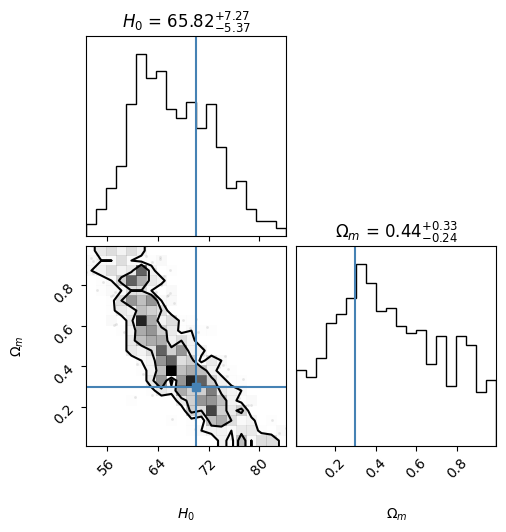

In [27]:
import corner

fig = corner.corner(flat_samples, labels=["$H_0$", "$\Omega_m$"], levels=[0.68,0.95], show_titles=True, truths=[70, 0.3])

# Mediana e incertezze (68% CL)
h0_mcmc, om_mcmc = np.median(flat_samples, axis=0)
h0_std, om_std = np.std(flat_samples, axis=0)

print(f"H0 measured: {h0_mcmc:.2f} +/- {h0_std:.2f}")
print(f"Omega_m measured: {om_mcmc:.3f} +/- {om_std:.3f}")

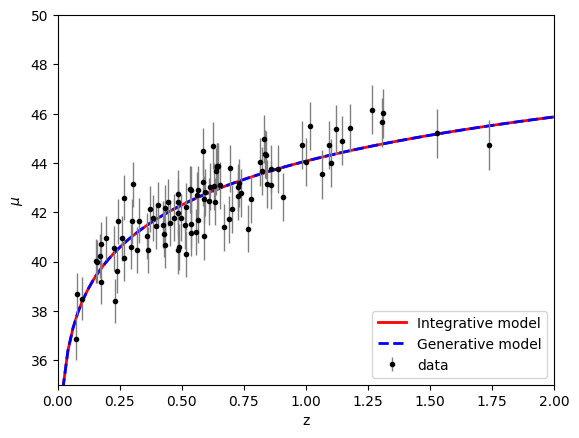

In [37]:
zlin = np.linspace(0,2,100)[1:]
plt.plot(zlin, mu_model_v(zlin, h0_mcmc, om_mcmc),c='red', lw=2, label='Integrative model')
plt.plot(zlin, generativemodel(zlin, h0_mcmc, om_mcmc),linestyle='--', c='blue', lw=2, label='Generative model')
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend(loc='lower right')

In [34]:
# Likelihood of none DE model (fix om=1)
log_L_no_DE = log_likelihood([h0_mcmc, 1.0], z_sample, mu_sample, dmu)
log_L_LCDM = log_likelihood([h0_mcmc, om_mcmc], z_sample, mu_sample, dmu)

bic_LCDM = 2 * np.log(len(z_sample)) - 2 * log_L_LCDM
bic_no_DE = 1 * np.log(len(z_sample)) - 2 * log_L_no_DE

delta_bic = bic_no_DE - bic_LCDM
print(f"Delta BIC: {delta_bic:.2f}")

Delta BIC: 6.09


### Nested Sampling

In [39]:
import dynesty
import scipy

In [66]:
ndim = 2


def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  #ausiliar vector

    x[0] = scipy.stats.uniform(loc=50,scale=50).ppf(u[0]) #H0
    x[1] = scipy.stats.uniform(loc=0,scale=1).ppf(u[1]) #Om
   


    return x

In [67]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(log_likelihood, ptform, ndim, logl_args=[z_sample,mu_sample, dmu],  nlive=400)
#sampler.run_nested()
#sresults = sampler.results

In [68]:
sampler.run_nested()
sresults = sampler.results

0it [00:00, ?it/s]

1246it [02:53,  7.18it/s, +400 | bound: 0 | nc: 1 | ncall: 11085 | eff(%): 15.405 | loglstar:   -inf < -132.813 <    inf | logz: -134.874 +/-  0.045 | dlogz:  0.001 >  0.409]


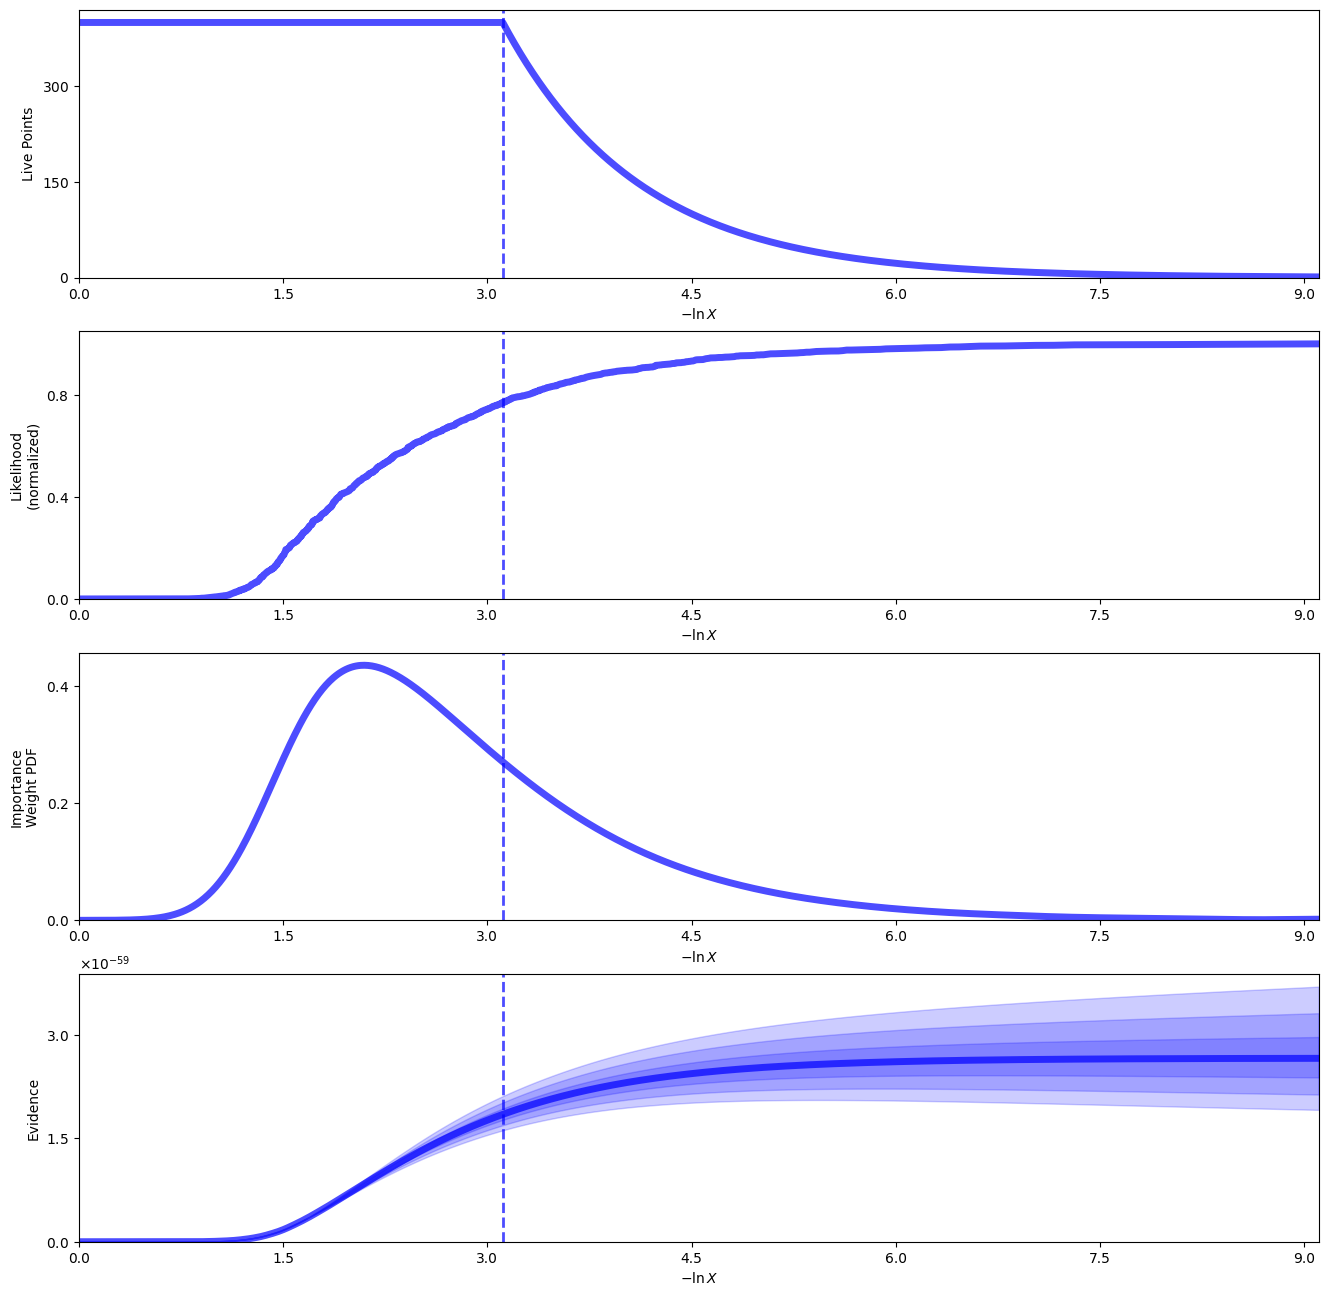

In [69]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

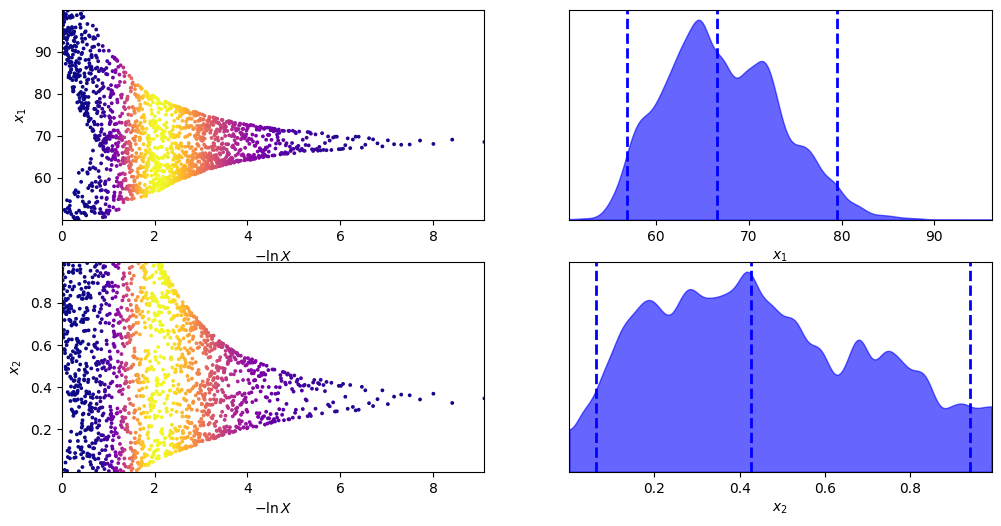

In [70]:
tfig, taxes = dyplot.traceplot(sresults)

H0: 66.62 +6.72 -5.88
Om: 0.43 +0.32 -0.24


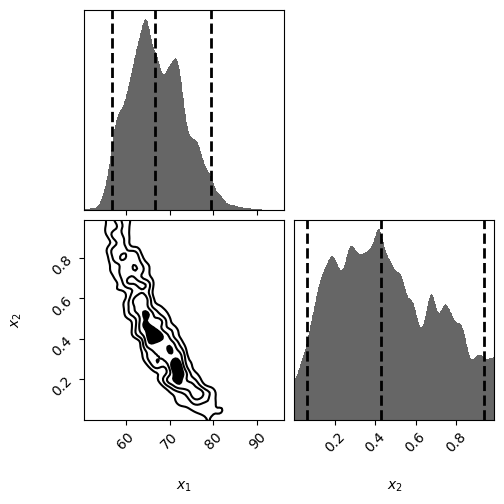

In [71]:
from dynesty import utils as dyfunc

samples = sresults.samples
weights = np.exp(sresults.logwt - sresults.logz[-1])

quantiles = [dyfunc.quantile(samps, [0.16, 0.5, 0.84], weights=weights)
             for samps in samples.T]

for name, q in zip(["H0", "Om"], quantiles):
    lo, med, hi = q
    print(f"{name}: {med:.2f} +{hi-med:.2f} -{med-lo:.2f}")

cfig, caxes = dyplot.cornerplot(sresults)


In [72]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 2.6594733432721026e-59
68% parameter credible regions are:
 [[60.73469038543826, 73.3379501322239], [0.18408671465746104, 0.7444966488213085]]

Mean and covariance of parameters are: [67.0961316   0.45481332]
[[37.65230967 -1.33209224]
 [-1.33209224  0.06165186]]


In [73]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,['H0', 'Om']):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

H0   66.61780700098423 +11.116078403362323 -8.884879471928706
Om   0.4276535297263934 +0.4651921396202277 -0.337692599149927


In [74]:

sresults.summary()

Summary
nlive: 400
niter: 1246
ncall: 10685
eff(%): 15.405
logz: -134.874 +/-  0.110


In [75]:
ndim = 2


def ptform_2(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  #ausiliar vector

    x[0] = scipy.stats.uniform(loc=50,scale=50).ppf(u[0]) #H0
    #x[1] = scipy.stats.uniform(loc=0,scale=1).ppf(u[1]) #Om
   


    return x

def log_likelihood_2(theta, z, mu, dmu):
    h0 = theta[0]
    om =1 
    model = generativemodel(z, h0, om) #mu_model_v(z, h0, om) #
    sigma2 = dmu**2
    return -0.5 * np.sum((mu - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

In [76]:
# "Static" nested sampling.
sampler2 = dynesty.NestedSampler(log_likelihood_2, ptform_2, ndim, logl_args=[z_sample,mu_sample, dmu],  nlive=400)
sampler2.run_nested()
sresults2 = sampler2.results

1270it [03:45,  5.62it/s, +400 | bound: 0 | nc: 1 | ncall: 10588 | eff(%): 16.392 | loglstar:   -inf < -133.530 <    inf | logz: -135.617 +/-  0.043 | dlogz:  0.001 >  0.409]


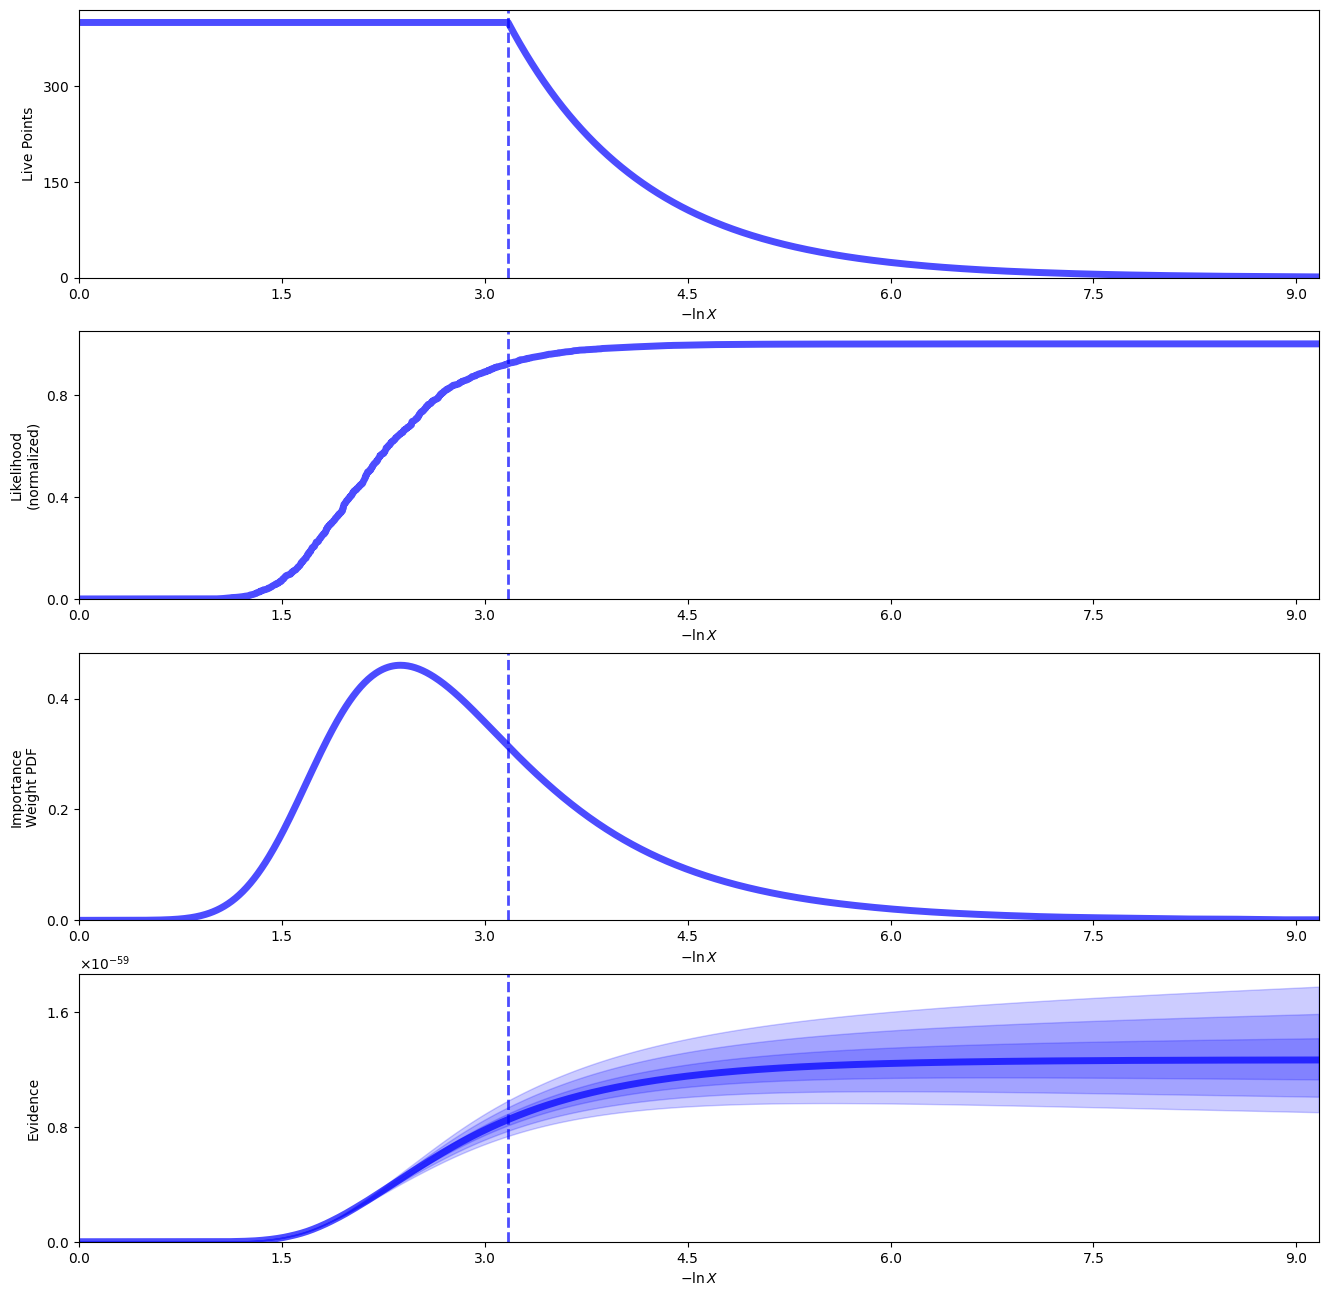

In [77]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults2)

H0: 57.72 +2.46 -2.41
Om: 0.49 +0.38 -0.33


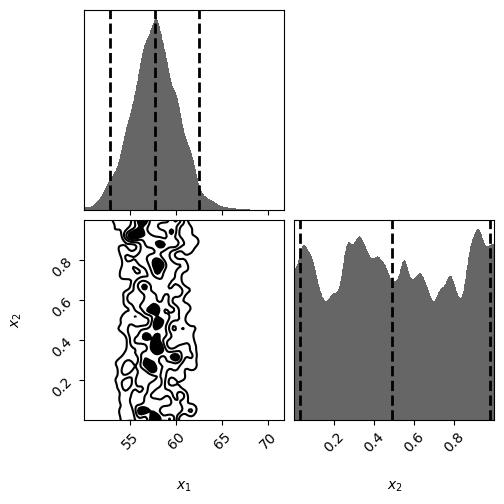

In [78]:
from dynesty import utils as dyfunc

samples = sresults2.samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])

quantiles = [dyfunc.quantile(samps, [0.16, 0.5, 0.84], weights=weights)
             for samps in samples.T]

for name, q in zip(["H0", "Om"], quantiles):
    lo, med, hi = q
    print(f"{name}: {med:.2f} +{hi-med:.2f} -{med-lo:.2f}")

cfig, caxes = dyplot.cornerplot(sresults2)

In [79]:
np.exp(sampler.results.logz[-1])/np.exp(sampler2.results.logz[-1])

np.float64(2.1021291616899522)

### Neural Network